EYT-Net uses two detection scales. Good anchor boxes should match the actual shapes in our data instead of defaults

We follow the usual YOLO practice as we researched:
- cluster on width/height only
- use 1 - IoU distance
- fit on train only, at 640×640 letterbox scale
- drop near-zero boxes

In [1]:
import sys
from pathlib import Path
import numpy as np
from PIL import Image
PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
DATA_DIR = PROJECT_ROOT / "data"
IMG_SIZE = 640

In [3]:
box_wh = []

for label_path in (DATA_DIR / "train" / "labels").glob("*.txt"): #train only
    text = label_path.read_text().strip()
    if not text:
        continue
    img_path = DATA_DIR / "train" / "images" / f"{label_path.stem}.jpg"
    orig_w, orig_h = Image.open(img_path).size
    scale = min(IMG_SIZE / orig_w, IMG_SIZE / orig_h)

    for line in text.splitlines():
        _, _, _, w, h = map(float, line.split())
        # convert normalized size to pixels at letterboxed resolution
        px_w = w * orig_w * scale
        px_h = h * orig_h * scale
        box_wh.append((px_w, px_h))

In [4]:
box_wh = np.array(box_wh)

In [5]:
len(box_wh), box_wh[:, 0].min(), box_wh[:, 0].max(), box_wh[:, 1].min(), box_wh[:, 1].max()

(4812,
 np.float64(3.5000000000000004),
 np.float64(639.5),
 np.float64(5.0),
 np.float64(359.5))

4812 train boxes at the 640 letterbox scale. Widths run 3.5–640 px, heights 5–360 px. so we have tiny objects and nearly full frame ones in the same set. That spread is exactly why dataset based anchors matter more than COCO defaults

Normal k-means uses Euclidean distance but that pulls the centers toward big boxes and ignores the small ones. For anchors we care about shape overlap so we measure distance as 1 - IoU as YOLO best practices show

All boxes are treated as if they share the same origin we only compare width and height

In [6]:
def box_iou(box, clusters):
    inter_w = np.minimum(clusters[:, 0], box[0])
    inter_h = np.minimum(clusters[:, 1], box[1])
    inter = inter_w * inter_h
    union = box[0] * box[1] + clusters[:, 0] * clusters[:, 1] - inter
    return inter / union

For each ground-truth box we take its best match to any cluster then average those scores. Higher = anchors cover the dataset better.

In [7]:
def avg_iou(boxes, clusters):
    return np.mean([np.max(box_iou(box, clusters)) for box in boxes])

Now we will implement k-means with IoU distance

In [8]:
def kmeans_iou(boxes, k, max_iter=100, seed=42):
    rng = np.random.default_rng(seed=seed)
    centers = boxes[rng.choice(len(boxes), size=k, replace=False)].copy()

    for _ in range(max_iter):
        dist = np.array([1 - box_iou(box, centers) for box in boxes])
        labels = np.argmin(dist, axis=1)

        new_centers = centers.copy()
        for i in range(k):
            members = boxes[labels == i]
            if len(members):
                new_centers[i] = np.median(members, axis=0) # for outliers median is better than mean. We use because box sizes are skewed

        if np.allclose(new_centers, centers):
            break
        centers = new_centers
    areas = centers[:, 0] * centers[:, 1] #find areas of the boxes to sort them by area
    return centers[np.argsort(areas)]

We try k = 1..9 and plot average IoU. EYT-Net has 2 scales, so 6 anchors (3 each) is a good pick.

In [9]:
ks = list(range(1, 10))
scores = []
for k in ks:
    anchors = kmeans_iou(box_wh, k=k, seed=42)
    score = avg_iou(box_wh, anchors)
    scores.append(score)
    print(f"k={k}: avg IoU = {score}")

k=1: avg IoU = 0.32238294498582387
k=2: avg IoU = 0.4597990058190611
k=3: avg IoU = 0.5416441345063986
k=4: avg IoU = 0.5945910857703476
k=5: avg IoU = 0.6228744774382615
k=6: avg IoU = 0.6379215170496142
k=7: avg IoU = 0.6567133216160382
k=8: avg IoU = 0.6718415843709982
k=9: avg IoU = 0.6876384526923621


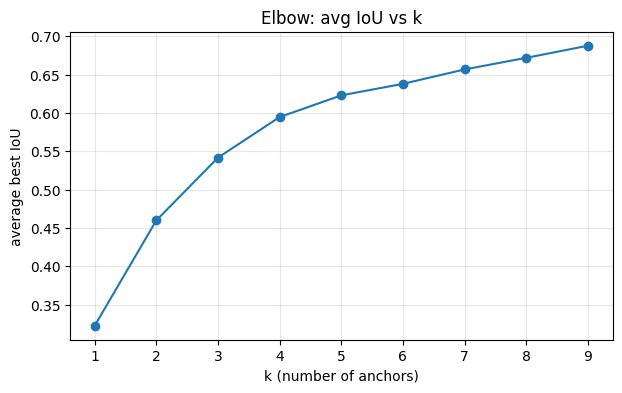

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(ks, scores, marker="o")
plt.xlabel("k (number of anchors)")
plt.ylabel("average best IoU")
plt.title("Elbow: avg IoU vs k")
plt.grid(True, alpha=0.3)
plt.show()

Avg IoU keeps rising as k grows, so we cannot just pick the k with the highest IoU from the plot. EYT-Net uses 2 detection scales, and we use 3 anchors per scale → k=6. After k=5, extra gains stay small so 6 is a reasonable choice. Avg IoU at k=6 is ≈ 0.64.

In [11]:
K = 6
anchors = kmeans_iou(box_wh, k=K, seed=42)
print(f"avg IoU @ k={K}: {avg_iou(box_wh, anchors):.3f}")
print("anchors (w, h) in pixels @ 640:")
for i, (w, h) in enumerate(anchors):
    print(f"  {i+1}: {w:.1f} x {h:.1f}  (area={w*h:.0f})")

avg IoU @ k=6: 0.638
anchors (w, h) in pixels @ 640:
  1: 9.5 x 11.0  (area=104)
  2: 21.0 x 22.5  (area=472)
  3: 36.0 x 48.0  (area=1728)
  4: 69.5 x 80.0  (area=5560)
  5: 110.5 x 148.5  (area=16409)
  6: 241.5 x 197.0  (area=47576)


Three small/medium boxes and three larger ones. Matches what we saw in EDA many tiny objects fewer big ones.

Now lets plot all train boxes and the 6 anchors on top.

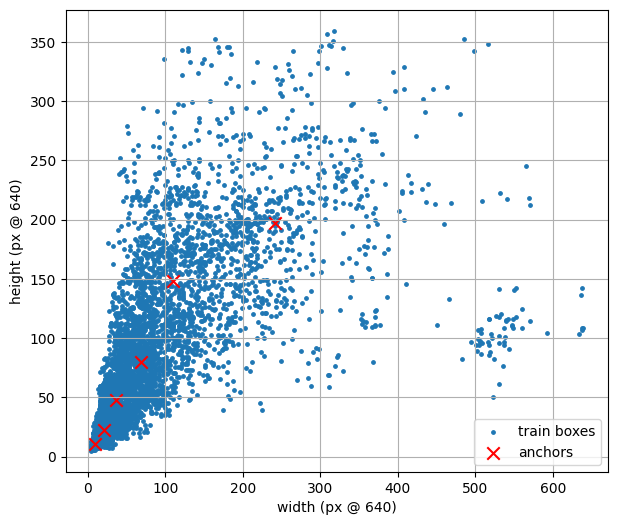

In [12]:
plt.figure(figsize=(7, 6))
plt.scatter(box_wh[:, 0], box_wh[:, 1], s=6, label="train boxes")
plt.scatter(anchors[:, 0], anchors[:, 1], s=80, c="red", marker="x", label="anchors")
plt.xlabel("width (px @ 640)")
plt.ylabel("height (px @ 640)")
plt.legend()
plt.grid(True)
plt.show()

Most boxes sit in the small corner. The three small anchors land in the dense area the three larger ones cover the long tail. Looks like a fair fit for this dataset.

In [13]:
import json
out_path = PROJECT_ROOT / "configs" / "anchors.json"
out_path.parent.mkdir(parents=True, exist_ok=True)
payload = {
    "img_size": IMG_SIZE,
    "seed": 42,
    "k": int(K),
    "avg_iou": float(avg_iou(box_wh, anchors)),
    "anchors_px": [[float(w), float(h)] for w, h in anchors],
}
out_path.write_text(json.dumps(payload, indent=2), encoding="utf-8")

345